# 06 - Comparacion de Modelos

Este notebook compara multiples modelos de clasificacion binaria para predecir `es_grave_o_mortal`. Se reutiliza exactamente el mismo dataset, target, features y particion train/test definidos en `05_entrenamiento.ipynb`, de modo que la comparacion sea justa y reproducible.

## Fundamento metodologico

Comparar modelos permite evaluar si distintas familias algoritmicas capturan mejor las relaciones entre variables de victima, contexto temporal y severidad del siniestro. Un modelo lineal como `LogisticRegression` funciona como referencia interpretable; un arbol de decision puede capturar reglas no lineales simples; y un `RandomForestClassifier` agrega muchos arboles para mejorar estabilidad y capacidad predictiva.

El target presenta desbalance: los casos graves o mortales son minoritarios frente a los leves. Por eso se usa `class_weight="balanced"` cuando el algoritmo lo permite, para penalizar mas los errores sobre la clase minoritaria. La metrica principal sera F1, porque resume precision y recall y resulta mas informativa que accuracy cuando el objetivo es detectar una clase poco frecuente.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_FILE = PROJECT_ROOT / "data" / "processed" / "siniestros_limpio_enriquecido.csv"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
COMPARISON_FILE = OUTPUTS_DIR / "model_comparison.json"

TARGET = "es_grave_o_mortal"
RANDOM_STATE = 42
TEST_SIZE = 0.2

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)

## Carga del dataset y definicion de features

Se utiliza `data/processed/siniestros_limpio_enriquecido.csv`. Las features son las mismas que en el baseline: variables temporales numericas y categorias de victima/contexto. Se excluyen variables asociadas al target o con riesgo de leakage, como `gravedad_victima`, `es_mortal` y `fecha_fallecimiento_victima`.

In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"No se encontro {DATA_FILE}. Ejecute primero notebooks/02_preprocessing.ipynb."
    )

df = pd.read_csv(DATA_FILE, parse_dates=["fecha_siniestro"])

numeric_features = [
    "anio_siniestro",
    "mes_siniestro",
    "dia_semana_siniestro",
    "trimestre_siniestro",
]

categorical_features = [
    "modo_desplazamiento_victima",
    "sexo_victima",
    "rol_victima",
    "edad_grupo",
    "vulnerabilidad_usuario",
]

excluded_features = [
    "GRAVEdad_victima",
    "gravedad_victima",
    "es_mortal",
    "es_grave_o_mortal",
    "fecha_fallecimiento_victima",
]

missing_required = [feature for feature in numeric_features + categorical_features + [TARGET] if feature not in df.columns]
if missing_required:
    raise KeyError(f"Faltan columnas requeridas para replicar el baseline: {missing_required}")

selected_features = numeric_features + categorical_features
model_df = df[selected_features + [TARGET]].copy()
model_df[categorical_features] = model_df[categorical_features].fillna("SIN_DATO")

X = model_df[selected_features]
y = model_df[TARGET]

print(f"Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Target: {TARGET}")
print(f"Features usadas: {len(selected_features)}")
display(pd.DataFrame({"feature": selected_features}))
display(pd.DataFrame({"variable_excluida": excluded_features, "presente_en_df": [col in df.columns for col in excluded_features]}))

Dataset: 62076 filas x 14 columnas
Target: es_grave_o_mortal
Features usadas: 9


,feature
0,anio_siniestro
1,mes_siniestro
2,dia_semana_siniestro
3,trimestre_siniestro
4,modo_desplazamiento_victima
5,sexo_victima
6,rol_victima
7,edad_grupo
8,vulnerabilidad_usuario


,variable_excluida,presente_en_df
0,GRAVEdad_victima,False
1,gravedad_victima,True
2,es_mortal,True
3,es_grave_o_mortal,True
4,fecha_fallecimiento_victima,False


## Split reproducible

Se mantiene el mismo `train_test_split` del notebook `05_entrenamiento.ipynb`: `test_size=0.2`, `random_state=42` y `stratify=y`. La estratificacion conserva la proporcion de clases en entrenamiento y prueba, algo central cuando existe desbalance.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "filas": [len(X_train), len(X_test)],
    "positivos": [int(y_train.sum()), int(y_test.sum())],
    "tasa_positiva": [float(y_train.mean()), float(y_test.mean())],
})

display(split_summary)

,split,filas,positivos,tasa_positiva
0,train,49660,2465,0.049638
1,test,12416,616,0.049613


## Modelos a comparar

- `LogisticRegression`: baseline lineal, interpretable y eficiente. Su desventaja es que puede subrepresentar relaciones no lineales si no se agregan interacciones o transformaciones.
- `DecisionTreeClassifier`: modelo basado en reglas, facil de explicar y capaz de capturar no linealidades. Su principal riesgo es el sobreajuste si el arbol crece demasiado.
- `RandomForestClassifier`: ensamble de arboles que suele mejorar estabilidad y generalizacion. Su costo es menor interpretabilidad y mayor tiempo de entrenamiento frente a un unico arbol.

In [4]:
def build_pipeline(estimator):
    preprocessor = ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("numeric", "passthrough", numeric_features),
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", estimator),
        ]
    )


models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
    "DecisionTreeClassifier": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_depth=8,
        min_samples_leaf=50,
    ),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1,
        min_samples_leaf=20,
    ),
}

models

{'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'DecisionTreeClassifier': DecisionTreeClassifier(class_weight='balanced', max_depth=8,
                        min_samples_leaf=50, random_state=42),
 'RandomForestClassifier': RandomForestClassifier(class_weight='balanced', min_samples_leaf=20,
                        n_estimators=200, n_jobs=-1, random_state=42)}

## Entrenamiento y evaluacion

Todos los modelos se entrenan sobre el mismo conjunto de entrenamiento y se evaluan sobre el mismo conjunto de test. Se reportan accuracy, precision, recall y F1 para la clase positiva (`grave o mortal`).

In [5]:
results = []
detailed_results = {}

for model_name, estimator in models.items():
    print(f"Entrenando {model_name}...")
    pipeline = build_pipeline(estimator)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "f1": float(f1_score(y_test, y_pred, zero_division=0)),
    }
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
    report_text = classification_report(y_test, y_pred, zero_division=0)

    results.append({"modelo": model_name, **metrics})
    detailed_results[model_name] = {
        "metrics": metrics,
        "confusion_matrix": conf_matrix.tolist(),
        "classification_report": report_dict,
        "prediction_distribution": pd.Series(y_pred).value_counts().sort_index().to_dict(),
    }

    print(f"\nClassification report - {model_name}")
    print(report_text)
    print(f"Confusion matrix - {model_name}")
    print(conf_matrix)
    print("-" * 80)

comparison_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
display(comparison_df)

Entrenando LogisticRegression...


c:\Users\Germán\Desktop\TP AVANZADA\tp-final-siniestros-viales\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification report - LogisticRegression
              precision    recall  f1-score   support

           0       0.99      0.64      0.78     11800
           1       0.12      0.94      0.21       616

    accuracy                           0.65     12416
   macro avg       0.56      0.79      0.49     12416
weighted avg       0.95      0.65      0.75     12416

Confusion matrix - LogisticRegression
[[7507 4293]
 [  40  576]]
--------------------------------------------------------------------------------
Entrenando DecisionTreeClassifier...

Classification report - DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.99      0.71      0.82     11800
           1       0.14      0.89      0.24       616

    accuracy                           0.72     12416
   macro avg       0.56      0.80      0.53     12416
weighted avg       0.95      0.72      0.80     12416

Confusion matrix - DecisionTreeClassifier
[[8331 3469]
 [  66  550]]
--

,modelo,accuracy,precision,recall,f1
0,RandomForestClassifier,0.720361,0.139576,0.897727,0.241590
1,DecisionTreeClassifier,0.715287,0.136850,0.892857,0.237325
2,LogisticRegression,0.651015,0.118299,0.935065,0.210027


## Matrices de confusion por modelo

Las matrices permiten identificar si cada algoritmo mejora la deteccion de casos graves o mortales o si simplemente favorece la clase mayoritaria.

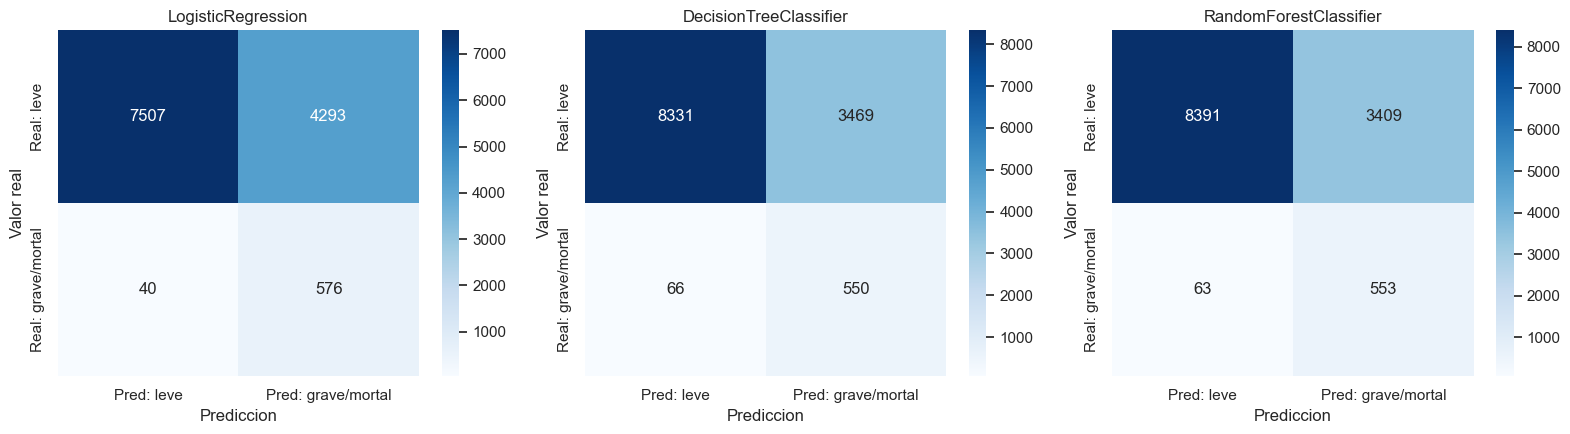

In [6]:
fig, axes = plt.subplots(1, len(models), figsize=(16, 4.5))

for ax, model_name in zip(axes, models.keys()):
    conf_matrix = detailed_results[model_name]["confusion_matrix"]
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred: leve", "Pred: grave/mortal"],
        yticklabels=["Real: leve", "Real: grave/mortal"],
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Valor real")

plt.tight_layout()
plt.show()

## Grafico comparativo de metricas

F1 se usa como criterio principal porque balancea precision y recall. En seguridad vial, un buen modelo no deberia limitarse a tener alta accuracy por predecir la clase mayoritaria; tambien debe recuperar una proporcion razonable de eventos graves o mortales sin producir demasiadas alertas incorrectas.

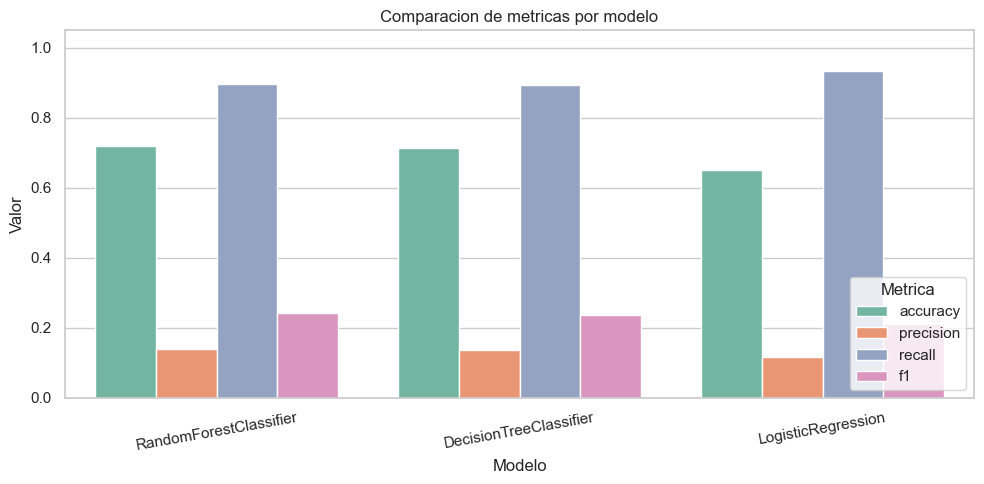

In [7]:
metrics_long = comparison_df.melt(
    id_vars="modelo",
    value_vars=["accuracy", "precision", "recall", "f1"],
    var_name="metrica",
    value_name="valor",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=metrics_long, x="modelo", y="valor", hue="metrica", ax=ax)
ax.set_title("Comparacion de metricas por modelo")
ax.set_xlabel("Modelo")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=10)
ax.legend(title="Metrica", loc="lower right")
plt.tight_layout()
plt.show()

## Seleccion objetiva del mejor modelo

La seleccion se realiza automaticamente usando F1 como criterio principal. En caso de empate exacto, el orden resultante conserva la mejor posicion segun el ordenamiento de la tabla comparativa.

In [8]:
best_row = comparison_df.iloc[0]
best_model = best_row["modelo"]

print(f"Mejor modelo segun F1: {best_model}")
display(best_row.to_frame(name="valor"))

Mejor modelo segun F1: RandomForestClassifier


,valor
modelo,RandomForestClassifier
accuracy,0.720361
precision,0.139576
recall,0.897727
f1,0.24159


## Exportacion de resultados

Los resultados se guardan en `outputs/model_comparison.json`, incluyendo tabla comparativa, mejor modelo, configuracion de datos y detalles por algoritmo. Este archivo deja trazabilidad para decisiones posteriores de produccion o nuevas iteraciones experimentales.

In [9]:
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

comparison_payload = {
    "target": TARGET,
    "hypothesis": "Las caracteristicas de la victima y del contexto del siniestro permiten anticipar si el caso terminara siendo grave o mortal.",
    "selection_metric": "f1",
    "best_model": best_model,
    "best_model_metrics": best_row.drop(labels=["modelo"]).to_dict(),
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "features": {
        "numeric": numeric_features,
        "categorical": categorical_features,
        "excluded_leakage_or_target": excluded_features,
    },
    "data": {
        "n_rows": int(len(df)),
        "n_features": int(len(selected_features)),
        "train_rows": int(len(X_train)),
        "test_rows": int(len(X_test)),
        "train_positive_rate": float(y_train.mean()),
        "test_positive_rate": float(y_test.mean()),
    },
    "comparison_table": comparison_df.to_dict(orient="records"),
    "models": detailed_results,
}

with COMPARISON_FILE.open("w", encoding="utf-8") as file:
    json.dump(comparison_payload, file, ensure_ascii=False, indent=2)

print(f"Resultados exportados en: {COMPARISON_FILE.resolve()}")

Resultados exportados en: C:\Users\Germán\Desktop\TP AVANZADA\tp-final-siniestros-viales\outputs\model_comparison.json


## Cierre

La comparacion formal permite elegir un candidato de manera objetiva bajo el criterio definido. La seleccion por F1 prioriza un equilibrio entre detectar casos graves o mortales y mantener precision razonable, aspecto especialmente importante en un dataset desbalanceado y orientado a prevencion vial.